In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:
adata = sc.read_h5ad('/lustre/groups/ml01/workspace/hpca/hpca_downstream/2026_final_object_healthy_hvg.h5ad')

In [4]:
# Scanpy / matplotlib color palettes for diabetes-extended pancreas atlas
# All category names and hex colors are quoted for consistency.
# Disease-associated states with suffix _T1D, _T2D, and _aab are assigned high-contrast colors.
hpca_colors = {
  'Level_3' : {
    'Pancreatic Polypeptide Cell': '#8e44ad',
    'Alpha Cell': '#e67e22',
    'Beta Cell': '#1f77b4',     
    'Ductal Cell': '#17becf',
    'Stellate Cell': '#a6761d',
    'Delta Cell': '#2ca02c',
    'Mixed Endocrine Cell': '#7f7f7f',
    'Pericyte': '#8c564b',
    'T Cell': '#d62728',
    'Epsilon Cell': '#bcbd22',
    'Schwann Cell': '#9467bd',
    'Endothelial Cell': '#1b9e77',
    'Acinar Cell': '#66a61e',
    'Mast Cell': '#e7298a',
    'Fibroblast': '#b15928',
    'Macrophage': '#ff7f0e',
    'NK Cell': '#fb9a99',
    'Smooth Muscle Cell': '#6a3d9a',
    'Plasma Cell': '#cab2d6',
    'Adipocyte': '#fdbf6f',
    'Delta Cell_T1D': '#e53935',
    'Beta Cell_T1D': '#8e24aa',
    'Alpha Cell_T1D': '#d81b60',
    'Pancreatic Polypeptide Cell_T1D': '#ad1457',
    'Alpha Cell_T2D': '#00acc1',
    'Beta Cell_T2D': '#1e88e5',
    'Delta Cell_T2D': '#00e5ff',
    'Pancreatic Polypeptide Cell_T2D': '#1565c0',
    'Beta Cell_aab': '#ffb300',
    'Alpha Cell_aab': '#fdd835',
    'Delta Cell_aab': '#ff8f00',
    'Pancreatic Polypeptide Cell_aab': '#f57f17',
  },
  'Dataset' : {
    'GSE101207_remapped': '#1f77b4',
    'GSE198623': '#ff7f0e',
    'GSE84133_remapped': '#2ca02c',
    'GSE183568': '#d62728',
    'Karakose': '#9467bd',
    'Tabula_Sapiens': '#8c564b',
    'GSE150724': '#e377c2',
    'GSE114297_remapped': '#7f7f7f',
    'HPAP': '#bcbd22',
    'Espace': '#17becf',
    'charite_snRNA': '#393b79',
    'Jimenez': '#637939',
    'GSE251913': '#8c6d31'
  },
  'suspension_type' : { 
    'cell': '#4c78a8',
    'nucleus': '#f58518',
  },
  'Level_4_extension_diabetes_simplified' : { 
    'Pancreatic Polypeptide Cell': '#562097',
    'Alpha Cell: GCG_Mid': '#974d20',
    'Beta Cell: Secretory Granules': '#206b97',
    'Alpha Cell: GCG_High': '#b26722',
    'Ductal Cell: Oxidative Stress': '#20978a',
    'Alpha Cell: Interferon Response': '#cf8822',
    'Alpha Cell: High OxPhos': '#e16f2c',
    'Beta Cell: Immediate Early Activation': '#216bb0',
    'Beta Cell: Interferon Response': '#2166c9',
    'Ductal Cell: CFTR Transport': '#23b8b8',
    'Beta Cell: INS_Mid, IAPP_High': '#239ae0',
    'Beta Cell: Oxidative Stress': '#4591d7',
    'Beta Cell: Dedifferentiation-like': '#568fdf',
    'Alpha Cell: Dedifferentiation-like': '#da9250',
    'Stellate Cell: Quiescent': '#973020',
    'Alpha Cell: ER Stress': '#e2ae65',
    'Delta Cell': '#289720',
    'Pancreatic Polypeptide Cell: ER Stress': '#8026c8',
    'Beta Cell: INS_Low': '#69b7e6',
    'Alpha-Beta-Delta Cell': '#e9a37a',
    'Alpha Cell: Mature Identity': '#efbe90',
    'Alpha Cell: Oxidative Stress': '#a36e23',
    'Alpha Cell: GCG_Low': '#be5d24',
    'Beta Cell: ER Stress': '#7cb6ec',
    'Ductal Cell: Centroacinar Cell': '#24c7db',
    'Delta Cell: High OxPhos': '#25c22b',
    'Delta Cell: Oxidative Stress': '#38de51',
    'Ductal Cell: EMT Transition': '#3fe4d2',
    'Ductal Cell: Injury Reactive': '#68dfdf',
    'Beta Cell: High OxPhos': '#98b9e9',
    'Beta Cell: Ion Channel Activity': '#1f73a5',
    'Alpha Cell: Proliferating': '#db7c24',
    'Ductal Cell: Proliferating': '#83dde8',
    'Beta Cell: Proliferating': '#1f72be',
    'Pancreatic Polypeptide Cell: Oxidative Stress': '#ac43e0',
    'Delta Cell: ER Stress': '#68e85e',
    'Ductal Cell: Mucin Secretion': '#9fefe6',
    'Pancreatic Polypeptide Cell: High OxPhos': '#a66eea',
    'Pericyte': '#d75228',
    'Pancreatic Polypeptide Cell: Interferon Response': '#cba3eb',
    'T Cell: CD8+': '#97203b',
    'Pancreatic Polypeptide Cell: Proliferating': '#8121b1',
    'Delta Cell: Interferon Response': '#8fe792',
    'Epsilon Cell': '#d7c142',
    'Beta Cell: Mature Identity': '#1f6bd8',
    'Ductal Cell: Interferon Response': '#19b1b1',
    'Delta Cell: Proliferating': '#21ae36',
    'Schwann Cell': '#e58f61',
    'Ductal Cell': '#2ab3c3',
    'Endothelial Cell: Vascular': '#209760',
    'Delta Cell: Dedifferentiation-like': '#30db24',
    'Beta Cell: INS_High': '#3b9cd5',
    'Beta Cell: INS_Mid': '#4c97dd',
    'Stellate Cell: Activated': '#f1a89d',
    'Acinar Cell: Quiescent': '#699720',
    'Mast Cell': '#972220',
    'Alpha Cell: GCG_Low, POU6F2_High': '#e39d39',
    'Acinar Cell: Digestive Secretion': '#6fbb23',
    'Acinar Cell: Oxidative Stress': '#6fdc2a',
    'Acinar Cell: CBS': '#a7e547',
    'Acinar Cell: Transitional': '#aae172',
    'Ductal Cell: SLC4A4_pos': '#37d9c8',
    'Fibroblast: CAF-like': '#b54927',
    'Ductal Cell: Ionocyte Like': '#52e3e3',
    'Acinar Cell: Interferon Response': '#b3ea90',
    'Acinar Cell: ADM Plasticity': '#75ae1d',
    'Acinar Cell: Proliferating': '#79d41e',
    'Acinar Cell: Injury Response': '#7cd742',
    'Macrophage: Proliferating': '#d94834',
    'Beta Cell: INS_High, IAPP_Low': '#5e95e4',
    'Acinar Cell: Idling': '#aee15f',
    'Macrophage: Activated': '#e9937a',
    'Acinar Cell': '#b3ea7d',
    'Endothelial Cell: Lymphatic': '#a1edd2',
    'Macrophage: Stressed': '#c61e1c',
    'Endothelial Cell': '#43e0b8',
    'Ductal Cell: PanIN': '#6eddea',
    'Treg: Resting': '#be2436',
    'Macrophage: Neural': '#dc6b5c',
    'Ductal Cell: Immature': '#94e8df',
    'Macrophage: Tissue resident': '#edb2a1',
    'Alpha Cell: GCG_High, IRX2_High': '#dc8c5c',
    'T Cell: Naive CD4+': '#dd3032',
    'B Cell': '#e75274',
    'Treg: Activated': '#e47f8b',
    'NK Cell': '#eda1a2',
    'T Cell: CM CD4+': '#b01d3e',
    'Smooth Muscle Cell': '#dc7b47',
    'Plasma Cell': '#d91f35',
    'Acinar Cell: PanIN': '#bef19d',
    'T Cell: Peripheral helper': '#d84a4c',
    'Treg: Proliferating': '#e36b86',
    'T Cell: EM CD4+': '#ec8c98',
    'Adipocyte': '#ea8e80',
    'Delta Cell_T1D': '#e53935',
    'Beta Cell_T1D': '#8e24aa',
    'Alpha Cell_T1D': '#d81b60',
    'Pancreatic Polypeptide Cell_T1D': '#ad1457',
    'Alpha Cell_T2D': '#00acc1',
    'Beta Cell_T2D': '#1e88e5',
    'Delta Cell_T2D': '#00e5ff',
    'Pancreatic Polypeptide Cell_T2D': '#1565c0',
    'Beta Cell_aab': '#ffb300',
    'Alpha Cell_aab': '#fdd835',
    'Delta Cell_aab': '#ff8f00',
    'Pancreatic Polypeptide Cell_aab': '#f57f17',
}
}

In [5]:
alpha_programs = {
"alpha_identity_mature": ["ARX","MAFB","IRX2","IRX1", "POU6F2", "GCG", "TTR", "CRYBA2"], #"PAX6"
"er_stress_upr": ["HSPA5","HSP90B1","XBP1","DDIT3","DNAJB9","HERPUD1","PDIA4"],
"inflammation_ifn": ["ISG15","IFIT1","IFIT2","MX1","OAS1","STAT1","IRF1"],
"oxidative_stress": ["TXNIP","HMOX1","NQO1","SOD2","SQSTM1","PRDX1"],
"cell_cycle": ["MKI67","TOP2A","CDK1","CCNB1","UBE2C","MCM5"],
"dedifferentiation_immature": ["HES1","ID1","ID3","SOX4","VIM","ALDH1A3"],
"oxphos_metabolic_state": ["NDUFS2","UQCRC2","COX5B","ATP5F1A","ATP5F1B","ATP5MC1","SDHB"]}

beta_programs = {
"beta_identity_mature": ["MAFA","PDX1","NKX6-1","RFX6","NEUROD1","UCN3","IAPP"],
"excitability_channels": ["KCNJ11","ABCC8","CACNA1D","RIMS2","SLC30A8","SYT7"],
"er_stress_upr": ["HSPA5","HSP90B1","XBP1","DDIT3","DNAJB9","HERPUD1","PDIA4"],
"inflammation_ifn": ["ISG15","IFIT1","IFIT2","MX1","OAS1","STAT1","IRF1"],
"ieg_activation": ["FOS","FOSB","JUN","JUND","EGR1","NR4A1","DUSP1"],
"oxidative_stress": ["TXNIP","HMOX1","NQO1","SOD2","SQSTM1","PRDX1"],
"cell_cycle": ["MKI67","TOP2A","CDK1","CCNB1","UBE2C","MCM5"],
"secretory_granule": ["CHGA","CHGB","SCG5","CPE", "PCSK1","PCSK2"],
# "ins_high": ["INS", "IAPP", "PCSK1", "CPE", "ERO1B"],
"dedifferentiation_immature": ["SOX9","HES1","ID1","ID3","VIM","ALDH1A3","SLC16A1","LDHA"],
"oxphos_metabolic_state": ["NDUFS2","UQCRC2","COX5B","ATP5F1A","ATP5F1B","ATP5MC1","SDHB"]
}

acinar_programs={
"acinar_digestive_secreting":["PRSS1","PRSS2","CPA1","CTRB1","CTRB2","CPB1","AMY2A","CELA2B","CLPS"],
"acinar_idling":["INSR","RBPJL","FOXP2","MAP3K5","KLF9","FOSL2"],
"acinar_reg_injury":["REG3A","REG3G","REG4","LCN2","S100A10","S100A11","CFD","LRIG1"],
"acinar_plasticity_adm":["SOX9","KRT19","MMP7","SPP1","KRT17","CLDN4","ANXA13"],
"oxidative_stress":["TXNIP","HMOX1","NQO1","SOD2","SQSTM1","PRDX1"], #"FTH1","FTL"
"cell_cycle":["MKI67","TOP2A","CDK1","CCNB1","UBE2C","MCM5"],
"inflammation_ifn": ["ISG15","IFIT1","IFIT2","MX1","OAS1","STAT1","IRF1"],
}

ductal_programs={
# "ductal_conventional":["KRT19","KRT7","SOX9","KRT8","KRT18","ANXA4","TACSTD2"],
"ductal_transport_cftr":["CFTR","SLC4A4","CA2","AQP1","CLDN4","SLC26A6"],
"ductal_mucinous":["MUC1","MUC5B","TFF1","TFF2","AGR2","SPDEF","KLF5"],
"ductal_reactive_injury":["SPP1","MMP7","KRT17","LGALS3","ANXA3","S100A10","LCN2"],
"ductal_emt_transitional":["VIM","ITGA6","SNAI2","ZEB1","TAGLN2","EMP1"],
"ductal_ionocyte_like":["FOXI1","CFTR","ASCL3","ATP6V1B1","ATP6V0D2","BSND"],
"oxidative_stress":["TXNIP","HMOX1","NQO1","SOD2","SQSTM1","PRDX1"], #"FTH1","FTL"
"cell_cycle":["MKI67","TOP2A","CDK1","CCNB1","UBE2C","MCM5"],
"inflammation_ifn": ["ISG15","IFIT1","IFIT2","MX1","OAS1","STAT1","IRF1"],
}

delta_programs = {"oxidative_stress":["TXNIP","HMOX1","NQO1","SOD2","SQSTM1","PRDX1"],
"cell_cycle":["MKI67","TOP2A","CDK1","CCNB1","UBE2C","MCM5"],
"inflammation_ifn": ["ISG15","IFIT1","IFIT2","MX1","OAS1","STAT1","IRF1"],
"er_stress_upr": ["HSPA5","HSP90B1","XBP1","DDIT3","DNAJB9","HERPUD1","PDIA4"],
"dedifferentiation_immature": ["SOX9","HES1","ID1","ID3","VIM","ALDH1A3","SLC16A1","LDHA"],
"oxphos_metabolic_state": ["NDUFS2","UQCRC2","COX5B","ATP5F1A","ATP5F1B","ATP5MC1","SDHB"]}

pp_programs = {"oxidative_stress":["TXNIP","HMOX1","NQO1","SOD2","SQSTM1","PRDX1"], 
"cell_cycle":["MKI67","TOP2A","CDK1","CCNB1","UBE2C","MCM5"],
"er_stress_upr": ["HSPA5","HSP90B1","XBP1","DDIT3","DNAJB9","HERPUD1","PDIA4"],
"inflammation_ifn": ["ISG15","IFIT1","IFIT2","MX1","OAS1","STAT1","IRF1"],
"oxphos_metabolic_state": ["NDUFS2","UQCRC2","COX5B","ATP5F1A","ATP5F1B","ATP5MC1","SDHB"]}
all_programs = {
    # alpha_programs
    "alpha_identity_mature": ["MAFB","ARX","IRX2","PDX1","PAX6","ISL1","MAFA"],
    "excitability_channels": ["KCNJ11","ABCC8","CACNA1D","CACNA1C","SLC30A8","SCGN","RIMS2","SYT7"],
    "er_stress_upr": ["HSPA5","HSP90B1","XBP1","DDIT3","DNAJB9","HERPUD1","PDIA4"],
    "inflammation_ifn": ["ISG15","IFIT1","IFIT2","MX1","OAS1","STAT1","IRF1"],
    "ieg_activation": ["FOS","FOSB","JUN","JUND","EGR1","NR4A1","DUSP1"],
    "oxidative_stress": ["TXNIP","HMOX1","NQO1","SOD2","SQSTM1","PRDX1"],
    "cell_cycle": ["MKI67","TOP2A","CDK1","CCNB1","UBE2C","MCM5"],
    "dedifferentiation_immature": ["SOX9","HES1","ID1","ID3","VIM","ALDH1A3","SLC16A1","LDHA"],
    "oxphos_metabolic_state": ["NDUFS2","UQCRC2","COX5B","ATP5F1A","ATP5F1B","ATP5MC1","SDHB"],
    # beta_programs
    "beta_identity_mature": ["MAFA","PDX1","NKX6-1","RFX6","NEUROD1","UCN3","IAPP"],
    "secretory_granule": ["CHGA","CHGB","SCG5","CPE", "PCSK1","PCSK2"],
    # acinar_programs
    "acinar_digestive_secreting": ["PRSS1","PRSS2","CPA1","CTRB1","CTRB2","CPB1","AMY2A","CELA2B","CLPS"],
    "acinar_idling": ["INSR","RBPJL","FOXP2","MAP3K5","KLF9","FOSL2"],
    "acinar_reg_injury": ["REG3A","REG3G","REG4","LCN2","S100A10","S100A11","CFD","LRIG1"],
    "acinar_plasticity_adm": ["SOX9","KRT19","MMP7","SPP1","KRT17","CLDN4","ANXA13"],
    # ductal_programs
    "ductal_transport_cftr": ["CFTR","SLC4A4","CA2","AQP1","CLDN4","SLC26A6"],
    "ductal_mucinous": ["MUC1","MUC5B","TFF1","TFF2","AGR2","SPDEF","KLF5"],
    "ductal_reactive_injury": ["SPP1","MMP7","KRT17","LGALS3","ANXA3","S100A10","LCN2"],
    "ductal_emt_transitional": ["VIM","ITGA6","SNAI2","ZEB1","TAGLN2","EMP1"],
    "ductal_ionocyte_like": ["FOXI1","CFTR","ASCL3","ATP6V1B1","ATP6V0D2","BSND"],
    # delta_programs
    "er_stress_upr": ["HSPA5","HSP90B1","XBP1","DDIT3","DNAJB9","HERPUD1","PDIA4"],
    # pp_programs (already merged above)
}

In [6]:
sc.set_figure_params(frameon=False, vector_friendly=True, dpi_save=300)

In [7]:
def add_program_scores(
    adata,
    programs: dict,
    group_cols=("Dataset", "suspension_type"),
    min_genes=3,
    score_suffix="_score",
    z_suffix="_z"):

    # Use only grouping columns that exist
    group_cols = [c for c in group_cols if c in adata.obs.columns]
    if len(group_cols) == 0:
        raise ValueError(
            "None of the requested group_cols exist in adata.obs. "
            "Add e.g. 'dataset' and/or 'suspension_type' columns, or change group_cols."
        )

    for prog, genes in programs.items():
        genes_present = [g for g in genes if g in adata.var_names]
        if len(genes_present) < min_genes:
            print(f"[skip] {prog}: only {len(genes_present)} genes present (<{min_genes}).")
            continue

        score_col = f"{prog}{score_suffix}"
        z_col = f"{prog}{score_suffix}{z_suffix}"

        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=score_col)

        # z-normalize within groups (dataset x suspension_type by default)
        def _z(x):
            sd = x.std(ddof=0)
            if sd == 0 or np.isnan(sd):
                return x * 0.0
            return (x - x.mean()) / sd

        adata.obs[z_col] = adata.obs.groupby(group_cols)[score_col].transform(_z)
        print(f"[ok] {prog}: scored with {len(genes_present)} genes -> {score_col}, {z_col}")

    return adata

In [8]:
def get_program_scores(adata, l3_cell_type, programs):
    adata_l3 = adata[adata.obs['Level_3'] == l3_cell_type]
    add_program_scores(adata_l3, programs)
    z_cols = adata_l3.obs.columns[adata_l3.obs.columns.str.contains('_z|Level_4$')]
    print(z_cols)
    mat = adata_l3.obs.loc[:, z_cols].groupby('Level_4').mean()
    mat.columns = mat.columns.str.replace('_score_z', '', regex=False)
    return mat


def compute_program_score_mats(adata, configs):
    """Compute program-score matrices for multiple lineages.

    configs: list of (Level_3 name, programs dict)
    """
    return {name: get_program_scores(adata, name, programs) for name, programs in configs}


In [9]:
lineage_configs = [
    ('Alpha Cell', alpha_programs),
    ('Beta Cell', beta_programs),
    ('Delta Cell', delta_programs),
    ('Acinar Cell', acinar_programs),
    ('Ductal Cell', ductal_programs),
    ('Pancreatic Polypeptide Cell', pp_programs),
]

lineage_mats = compute_program_score_mats(adata, lineage_configs)
alpha_mat = lineage_mats['Alpha Cell']

/home/icb/daniel.strobl/miniconda3/envs/scanpy_26/lib/python3.14/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
/tmp/ipykernel_700132/3376146998.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[z_col] = adata.obs.groupby(group_cols)[score_col].transform(_z)


[ok] alpha_identity_mature: scored with 8 genes -> alpha_identity_mature_score, alpha_identity_mature_score_z


/tmp/ipykernel_700132/3376146998.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[z_col] = adata.obs.groupby(group_cols)[score_col].transform(_z)


[ok] er_stress_upr: scored with 7 genes -> er_stress_upr_score, er_stress_upr_score_z


/tmp/ipykernel_700132/3376146998.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[z_col] = adata.obs.groupby(group_cols)[score_col].transform(_z)


...

/tmp/ipykernel_700132/3376146998.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[z_col] = adata.obs.groupby(group_cols)[score_col].transform(_z)


[ok] er_stress_upr: scored with 7 genes -> er_stress_upr_score, er_stress_upr_score_z


/tmp/ipykernel_700132/3376146998.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[z_col] = adata.obs.groupby(group_cols)[score_col].transform(_z)


[ok] inflammation_ifn: scored with 7 genes -> inflammation_ifn_score, inflammation_ifn_score_z
[ok] oxphos_metabolic_state: scored with 7 genes -> oxphos_metabolic_state_score, oxphos_metabolic_state_score_z
Index(['Level_4', 'oxidative_stress_score_z', 'cell_cycle_score_z',
       'er_stress_upr_score_z', 'inflammation_ifn_score_z',
       'oxphos_metabolic_state_score_z'],
      dtype='object')


/tmp/ipykernel_700132/3376146998.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[z_col] = adata.obs.groupby(group_cols)[score_col].transform(_z)
/tmp/ipykernel_700132/1995204889.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = adata_l3.obs.loc[:, z_cols].groupby('Level_4').mean()


In [10]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from scipy.optimize import linear_sum_assignment

#plt.figure(figsize=(13, 20))

#z_cols = obs_epi.columns[obs_epi.columns.str.endswith('_z')]
#mat = obs_epi.loc[:, z_cols].groupby('Level_4').mean()
#mat.columns = mat.columns.str.replace('_score_z', '', regex=False)


def _cluster_order(data):
    """Reorder rows/cols so similar profiles cluster."""
    dist = pdist(data, metric='correlation')
    Z = hierarchy.linkage(dist, method='average')
    Z = hierarchy.optimal_leaf_ordering(Z, data)
    return hierarchy.leaves_list(Z)


def _diagonal_order(mat):
    """Pair each program column to the best-matching lineage row (same index on both axes)."""
    row_ind, col_ind = linear_sum_assignment(-mat.values)
    pairs = sorted(zip(row_ind, col_ind), key=lambda x: x[1])

    row_order = [mat.index[r] for r, _ in pairs]
    col_order = [mat.columns[c] for _, c in pairs]

    assigned_rows = set(row_ind)
    extra_rows = [mat.index[i] for i in range(len(mat.index)) if i not in assigned_rows]
    if len(extra_rows) > 1:
        extra_idx = [list(mat.index).index(r) for r in extra_rows]
        sub_order = _cluster_order(mat.iloc[extra_idx].values)
        extra_rows = [extra_rows[i] for i in sub_order]

    assigned_cols = set(col_ind)
    extra_cols = [mat.columns[i] for i in range(len(mat.columns)) if i not in assigned_cols]
    if len(extra_cols) > 1:
        extra_idx = [list(mat.columns).index(c) for c in extra_cols]
        sub_order = _cluster_order(mat.iloc[:, extra_idx].values.T)
        extra_cols = [extra_cols[i] for i in sub_order]

    return row_order + extra_rows, col_order + extra_cols


def _score_cmap(color):
    """White at 0 and below; `color` at the maximum positive score."""
    return LinearSegmentedColormap.from_list('program_score', ['white', color])


_PAD = '__pad__'


def _prepare_matrix(mat):
    row_order, col_order = _diagonal_order(mat)
    return mat.loc[row_order, col_order]


def _pad_matrix(mat, nrows, ncols):
    row_names = list(mat.index) + [f'{_PAD}{i}' for i in range(nrows - len(mat))]
    col_names = list(mat.columns) + [f'{_PAD}{i}' for i in range(ncols - len(mat))]
    out = pd.DataFrame(np.nan, index=row_names, columns=col_names)
    out.iloc[: mat.shape[0], : mat.shape[1]] = mat.values
    return out


def _style_heatmap_ax(ax, xtickrotation=45, show_xlabels=True, show_ylabels=True):
    ax.collections[0].set_linewidths(0)
    ax.collections[0].set_edgecolor('face')
    ax.grid(False)

    if show_xlabels:
        ax.tick_params(axis='x', labelrotation=xtickrotation, bottom=True, labelbottom=True)
        for label in ax.get_xticklabels():
            label.set_ha('right')
            label.set_fontweight('bold')
            if label.get_text().startswith(_PAD):
                label.set_visible(False)
    else:
        ax.set_xticklabels([])
        ax.set_xlabel('')

    if show_ylabels:
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')
            if label.get_text().startswith(_PAD):
                label.set_visible(False)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel('')

    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')
    ax.title.set_fontweight('bold')


def _draw_program_heatmap(ax, mat, color, vmax, show_cbar=True, cbar_shrink=0.8,
                          xtickrotation=90, show_xlabels=True, show_ylabels=True):
    sns.heatmap(
        mat,
        cmap=_score_cmap(color),
        vmin=0,
        vmax=vmax,
        xticklabels=show_xlabels,
        yticklabels=show_ylabels,
        linewidths=0,
        linecolor='none',
        ax=ax,
        cbar=show_cbar,
        cbar_kws={'shrink': cbar_shrink},
    )
    _style_heatmap_ax(
        ax,
        xtickrotation=xtickrotation,
        show_xlabels=show_xlabels,
        show_ylabels=show_ylabels,
    )
    return ax


def _align_heatmap_axes(axes, ncols=3):
    """Normalize every panel to the same heatmap width/height in the grid."""
    ref = axes[0].get_position()
    w, h = ref.width, ref.height
    col_x = [axes[col].get_position().x0 for col in range(ncols)]
    row_y = [axes[row * ncols].get_position().y0 for row in range(len(axes) // ncols)]

    for idx, ax in enumerate(axes):
        row, col = divmod(idx, ncols)
        ax.set_position([col_x[col], row_y[row], w, h])


def plot_program_scores(mat, color, vmax=None, save_svg=None, figsize=None):
    mat = _prepare_matrix(mat)

    if vmax is None:
        vmax = np.nanmax(mat.values)
    vmax = max(float(vmax), 1e-9)

    nrows, ncols = mat.shape
    if figsize is None:
        figsize = (max(4.0, 0.85 * ncols + 2.5), max(3.0, 0.32 * nrows + 1.5))

    plt.close('all')
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    _draw_program_heatmap(ax, mat, color, vmax, show_cbar=True)

    if save_svg is not None:
        with plt.rc_context({'svg.fonttype': 'none'}):
            fig.savefig(save_svg, format='svg', bbox_inches='tight')

    return fig, ax


def plot_program_scores_grid(
    mats,
    titles,
    colors,
    vmax=None,
    save_svg=None,
    figsize=None,
    nrows=2,
    ncols=3,
):
    """Plot program-score heatmaps for multiple lineages in a 2x3 grid.

    mats: list of program-score DataFrames (raw, not reordered)
    titles: list of panel titles, same order as mats
    colors: list of lineage colors, same order as mats
    """
    mats = [_prepare_matrix(m) for m in mats]

    if vmax is None:
        vmax = max(np.nanmax(m.values) for m in mats)
    vmax = max(float(vmax), 1e-9)

    max_rows = max(m.shape[0] for m in mats)
    max_cols = max(m.shape[1] for m in mats)
    if figsize is None:
        figsize = (3.0 * max_cols + 7.0, 2.2 * max_rows + 8.0)

    plt.close('all')
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.asarray(axes).ravel()
    fig.subplots_adjust(hspace=0.7, wspace=1, top=0.4, bottom=0.06)

    for ax, mat, color, title in zip(axes, mats, colors, titles):
        _draw_program_heatmap(
            ax,
            mat,
            color,
            vmax,
            show_cbar=False,
            show_xlabels=True,
            show_ylabels=True,
        )
        ax.set_title(title, pad=10, fontweight='bold')
        ax.set_ylabel('', fontweight='bold')

    _align_heatmap_axes(axes, ncols=ncols)

    if save_svg is not None:
        with plt.rc_context({'svg.fonttype': 'none'}):
            fig.savefig(save_svg, format='svg', bbox_inches='tight')

    return fig, axes

In [11]:
lineage_mats['Pancreatic Polypeptide Cell'].index = lineage_mats['Pancreatic Polypeptide Cell'].index.str.replace('Pancreatic Polypeptide Cell', 'PP Cell')

(<Figure size 2400x3600 with 6 Axes>,
 array([<Axes: title={'center': 'Alpha Cell'}>,
        <Axes: title={'center': 'Beta Cell'}>,
        <Axes: title={'center': 'Delta Cell'}>,
        <Axes: title={'center': 'Acinar Cell'}>,
        <Axes: title={'center': 'Ductal Cell'}>,
        <Axes: title={'center': 'Pancreatic Polypeptide Cell'}>],
       dtype=object))

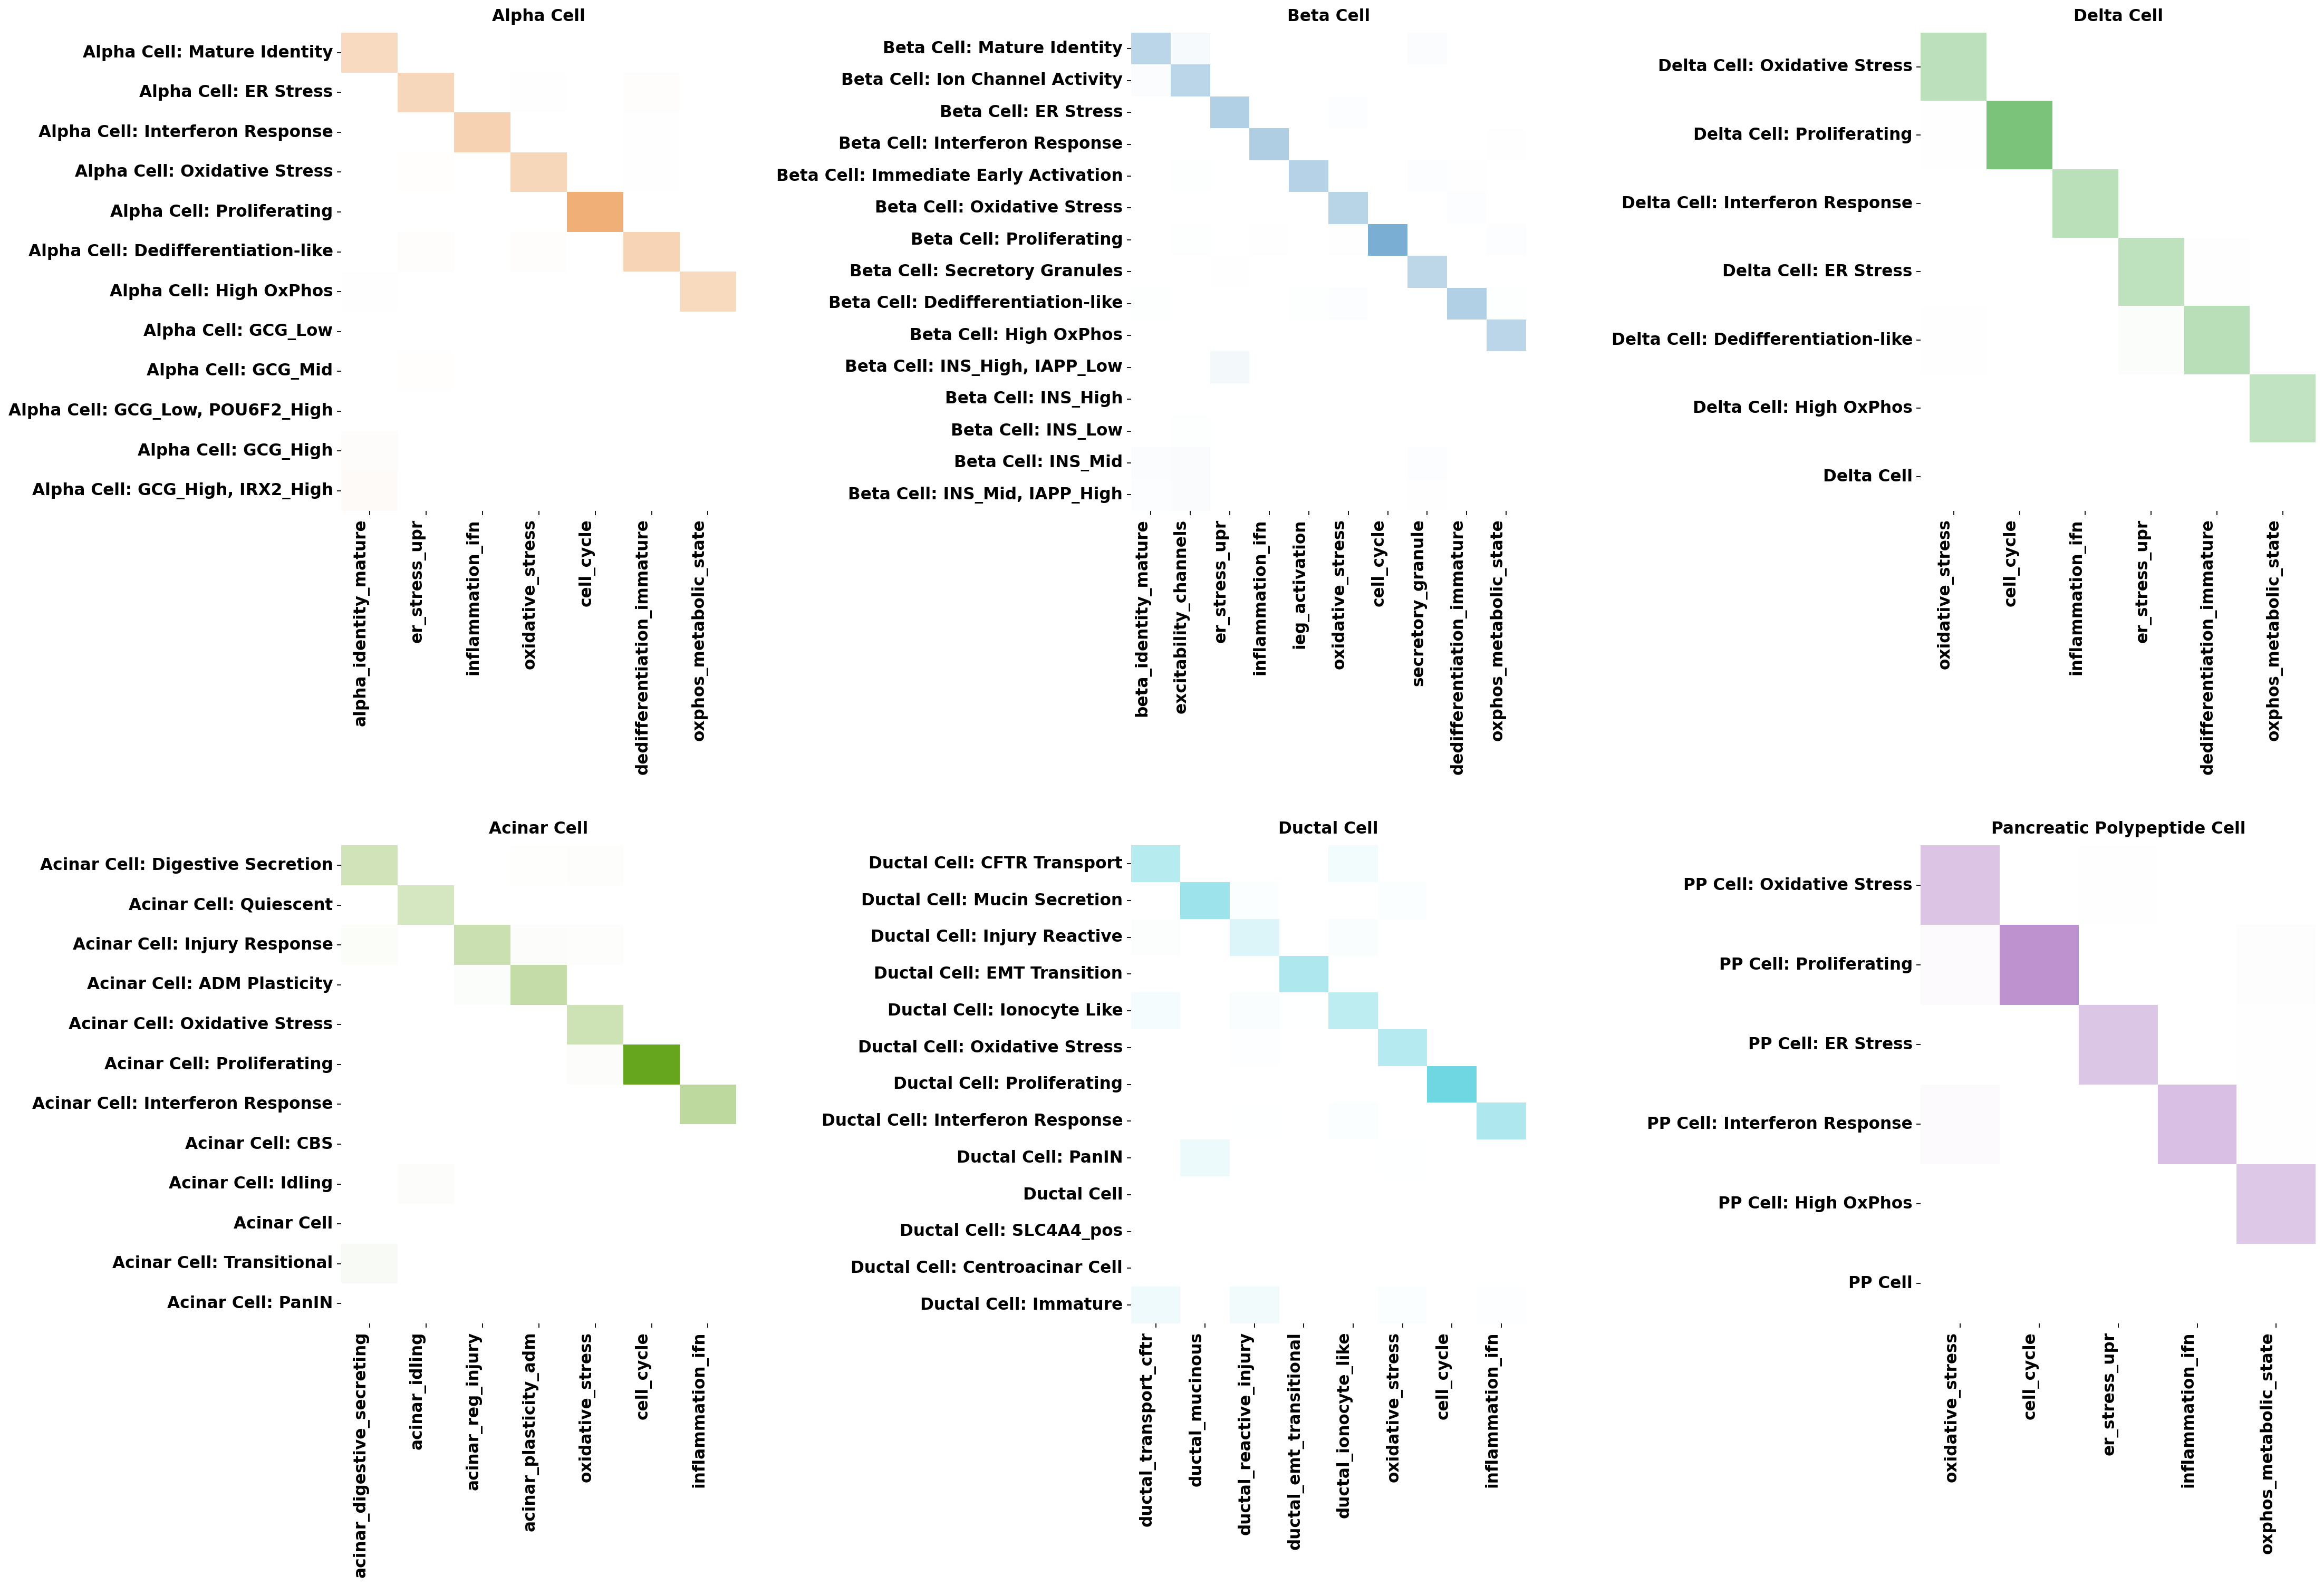

In [12]:
lineage_colors = [hpca_colors['Level_3'][name] for name, _ in lineage_configs]

plot_program_scores_grid(
    mats=[lineage_mats[name] for name, _ in lineage_configs],
    titles=[name for name, _ in lineage_configs],
    colors=lineage_colors,
    figsize=(30, 45),
    save_svg='/lustre/groups/ml01/workspace/hpca/hpca_downstream/annotation_plotting/all_lineage_programs.svg',
)

(<Figure size 1600x5600 with 6 Axes>,
 array([<Axes: title={'center': 'Alpha Cell'}>,
        <Axes: title={'center': 'Beta Cell'}>,
        <Axes: title={'center': 'Delta Cell'}>,
        <Axes: title={'center': 'Acinar Cell'}>,
        <Axes: title={'center': 'Ductal Cell'}>,
        <Axes: title={'center': 'Pancreatic Polypeptide Cell'}>],
       dtype=object))

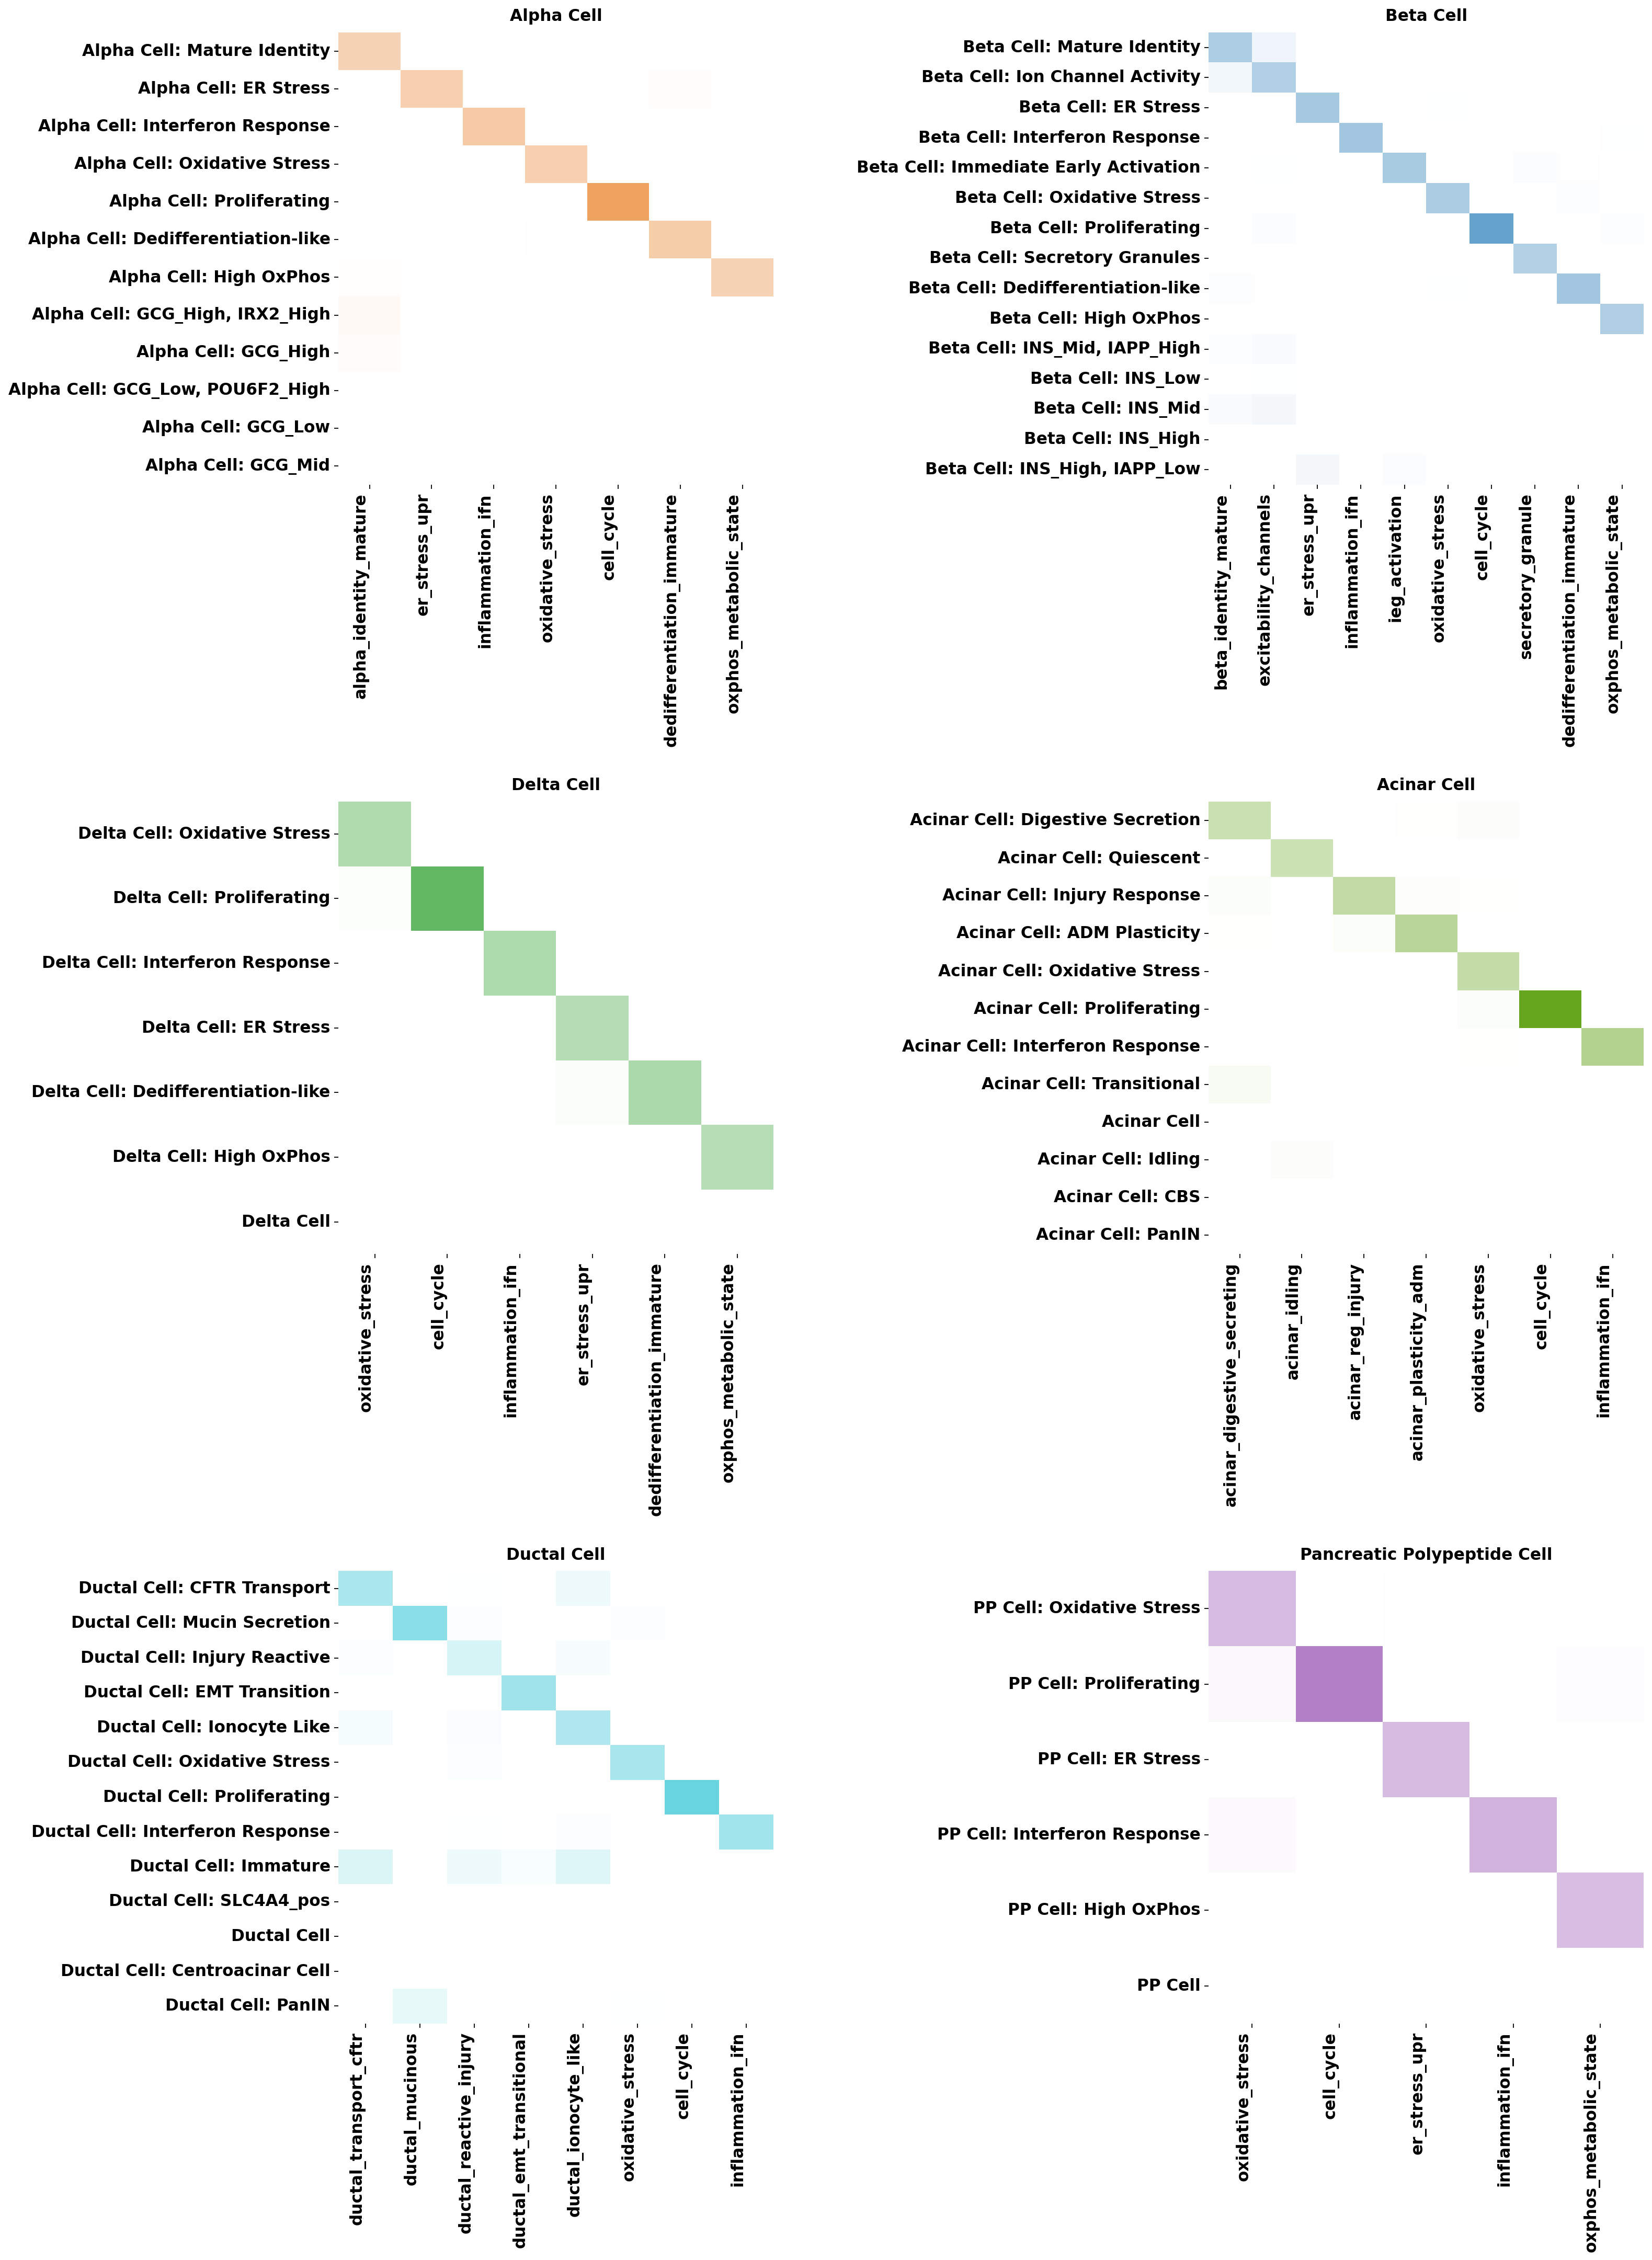

In [65]:
lineage_colors = [hpca_colors['Level_3'][name] for name, _ in lineage_configs]

plot_program_scores_grid(
    mats=[lineage_mats[name] for name, _ in lineage_configs],
    titles=[name for name, _ in lineage_configs],
    colors=lineage_colors,
    figsize=(20, 70),
    nrows=3,
    ncols=2,
    save_svg='/lustre/groups/ml01/workspace/hpca/hpca_downstream/annotation_plotting/all_lineage_programs_vertical.svg',
)